In [ ]:
# Credit Scoring Model #
# CodeAlpha Task 1 #


# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:

# Read Dataset
df = pd.read_csv("/content/german_credit_data.csv")


In [ ]:
# Display First 10 Rows
print(df.head())


   Unnamed: 0  Age  Sex  Job  Housing  Saving accounts  Checking account  \
0           0   67    1    2        1                0                 0   
1           1   22    0    2        1                0                 1   
2           2   49    1    1        1                0                 0   
3           3   45    1    2        0                0                 0   
4           4   53    1    2        0                0                 0   

   Credit amount  Duration  Purpose  
0           1169         6        5  
1           5951        48        5  
2           2096        12        3  
3           7882        42        4  
4           4870        24        1  


In [ ]:
# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64


In [ ]:
# Fill Missing Values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1909/2114804333.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
# Encode Categorical Columns
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

In [ ]:
# Display Dataset Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   int64
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   int64
 5   Saving accounts   1000 non-null   int64
 6   Checking account  1000 non-null   int64
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   int64
dtypes: int64(10)
memory usage: 78.3 KB
None


In [ ]:
# Target Column
# Replace 'Unnamed: 0' with your dataset target column if it's different
target = 'Unnamed: 0'

X = df.drop(target, axis=1)
y = df[target]

In [ ]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.2, random_state=42)


In [ ]:
# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
# Prediction
y_pred = model.predict(X_test)

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)


Accuracy: 0.0


In [ ]:
# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00       0.0
           8       0.00      0.00      0.00       0.0
          10       0.00      0.00      0.00       1.0
          16       0.00      0.00      0.00       0.0
          23       0.00      0.00      0.00       1.0
          25       0.00      0.00      0.00       1.0
          29       0.00      0.00      0.00       0.0
          30       0.00      0.00      0.00       1.0
          39       0.00      0.00      0.00       1.0
          44       0.00      0.00      0.00       1.0
          54       0.00      0.00      0.00       1.0
          55       0.00      0.00      0.00       1.0
          59       0.00      0.00      0.00       1.0
          60       0.00      0.00      0.00       1.0
          62       0.00      0.00      0.00       0.0
          63       0.00      0.00      0.00       1.0
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

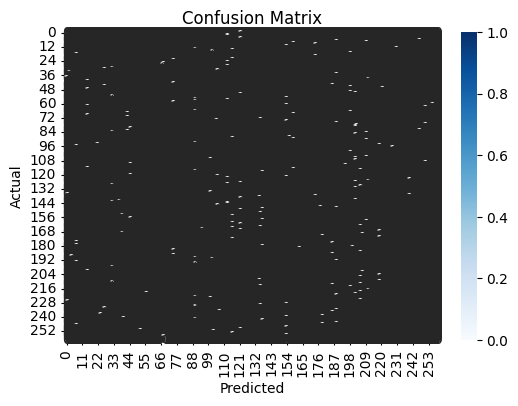

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()